# Visão Computacional no Varejo: Detecção de Prateleira Vazia (v2)

**1. Contexto de negócio**

Uma rede de varejo instala câmeras apontadas para as gôndolas e quer saber, de forma automática, quando uma seção precisa de reposição — sem depender de um repositor passando de corredor em corredor para checar visualmente.

Hoje o processo é manual: um repositor caminha pela loja algumas vezes ao dia e anota o que falta. Isso gera três problemas de negócio:

- **Ruptura de estoque não detectada a tempo** — o produto fica fora da gôndola por horas antes de alguém perceber, gerando venda perdida e migração do cliente para o concorrente.
- **Custo de mão de obra** em checagens repetitivas e de baixo valor agregado.
- **Falta de rastro auditável** — registramos quando a prateleira foi reposta, nunca quando ela esvaziou. Sem isso, não conseguimos nem medir o tamanho do problema.

A proposta é usar uma foto de cada seção de gôndola, tirada periodicamente pela câmera, e classificar automaticamente em duas categorias: **cheia** (tem produto suficiente) ou **precisa de reposição**.

---

**Este notebook é a versão 2 do caso.** A versão 1 (`05-visao-computacional-varejo.ipynb`) mostrou um resultado honesto e incômodo: com imagens simuladas de 16×16 pixels, a regra simples de brilho médio **venceu** a CNN, e o desempenho da rede oscilou de 40% a 83% nos casos difíceis apenas trocando a seed. A conclusão de lá foi que o ganho de uma rede neural não é automático — depende de haver estrutura visual real a explorar e dados suficientes para aprendê-la.

Esta versão testa exatamente essa hipótese, corrigindo as fraquezas metodológicas apontadas:

| Fraqueza da v1 | O que muda aqui |
|---|---|
| Imagens 16×16, sem variação de câmera | 64×64, com 8 câmeras de perfis diferentes (iluminação, contraste, vinheta, enquadramento) |
| Sem oclusão nem variação realista | Oclusão parcial (cliente/carrinho), reflexos, textura de embalagem |
| Split aleatório | **Split por câmera** — a rede é testada em câmeras que nunca viu |
| Só acurácia | Precisão, recall, F1, PR-AUC e matriz de confusão |
| Limiar de decisão fixo em 0,5 | **Calibração por custo de negócio** (falso negativo custa mais que falso positivo) |
| Baseline vs. CNN | Três níveis: limiar, features clássicas + boosting, e CNN com *augmentation* |
| Sem controle de sobreajuste | *Early stopping*, *dropout* e *data augmentation* |

**Limitações deste notebook**

Antes de prosseguir, as limitações continuam valendo e precisam estar claras:

- As imagens ainda são **simuladas**, não fotos reais de gôndola. A simulação é bem mais rica que a da v1 — variação de câmera, oclusão, reflexo, textura — mas continua sendo uma simulação. Fotos reais trazem uma diversidade visual que nenhum gerador sintético reproduz.
- O **rótulo é derivado da própria simulação** (fração de pixels ocupada por produto). Em produção, o rótulo vem de rotulagem humana, que tem ruído e discordância entre anotadores — especialmente na faixa ambígua.
- As acurácias obtidas aqui **não devem ser lidas como desempenho esperado em produção**. Elas medem o comportamento relativo dos três modelos neste dataset sintético.
- O que este notebook *pode* legitimamente demonstrar é a **comparação metodológica**: dado um problema com estrutura espacial real e validação honesta, qual abordagem se sai melhor e por quê.

**2. Por que testar três níveis de complexidade**

A tentação em um projeto de IA é ir direto à rede neural. O notebook v1 mostrou o custo dessa pressa. Aqui subimos a escada degrau por degrau, e cada degrau responde a uma pergunta:

1. **Limiar sobre o brilho médio** — *o problema se resolve só com "quanta luz tem na foto"?* É o que uma loja conseguiria implementar sem modelo nenhum. Zero parâmetros, interpretável, roda em microssegundos.
2. **Features clássicas + gradient boosting** — *e se eu descrever a imagem com algumas medidas espaciais escolhidas à mão?* A feature decisiva aqui é o **tamanho do maior componente conexo claro**: ela separa "bloco contíguo de produto" de "pontos de reflexo espalhados", que é justamente o que o brilho médio confunde.
3. **CNN com augmentation** — *e se eu deixar a rede descobrir sozinha quais padrões importam?* É o degrau mais caro em dados, tempo e interpretabilidade. Precisa provar que vale.

Se o degrau 3 não bater o degrau 1, a resposta certa para o negócio é ficar no degrau 1.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib` e `tensorflow`. Em Google Colab todas já vêm instaladas, então a célula abaixo apenas confirma isso.

In [1]:
%pip install -q numpy pandas scipy scikit-learn matplotlib tensorflow
print('Dependencias OK.')

Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, confusion_matrix,
                             precision_recall_curve, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
rng = np.random.default_rng(SEED)

print('TensorFlow:', tf.__version__)

I0000 00:00:1787767943.452288    6811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787767943.452879    6811 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1787767945.055356    6811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787767945.055807    6811 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


**3. Geração do dataset simulado**

Como não há acesso a fotos reais, simulamos imagens de **64×64 pixels** em escala de cinza. Cada imagem representa uma seção de gôndola com **três prateleiras**, e é construída em quatro camadas:

1. **Produto** — blocos retangulares de intensidade alta sobre cada prateleira, com textura interna (listras de embalagem). A fração de pixels ocupada por esses blocos é a **cobertura real**.
2. **Ruído de cena** — "manchas" isoladas de brilho alto (reflexo de embalagem plástica, etiqueta, ponto de luz). Elas **elevam o brilho médio da imagem sem representar produto** — é o ruído que derruba a regra de limiar. Prateleiras vazias e ambíguas recebem bem mais manchas.
3. **Oclusão** — em 20% das imagens, um bloco escuro simula um cliente ou carrinho passando na frente. Isso **derruba o brilho médio sem alterar o rótulo verdadeiro**, e é o tipo de ruído estrutural que só uma abordagem espacial consegue contornar.
4. **Perfil de câmera** — cada uma das 8 câmeras tem seu próprio ganho de contraste, offset de iluminação, vinheta (escurecimento nas bordas), deslocamento de enquadramento e nível de ruído de sensor. **Duas fotos da mesma prateleira em câmeras diferentes não se parecem.**

O rótulo segue a regra de negócio: a seção **precisa de reposição** quando a cobertura real de produto é **menor que 25%**.

> Atenção à convenção: aqui `y = 1` significa **precisa de reposição** (o evento que queremos detectar), invertendo a convenção da v1, onde `1` era "cheia". Isso torna precisão e recall diretamente legíveis em termos de negócio — *recall* passa a ser "das rupturas que existiram, quantas o modelo pegou".

In [3]:
TAMANHO = 64
N_LINHAS = 3
ALT_LINHA = TAMANHO // N_LINHAS
ALT_PRODUTO = ALT_LINHA - 6
COBERTURA_MAX = (N_LINHAS * ALT_PRODUTO) / TAMANHO   # cobertura maxima fisicamente possivel
LIMIAR_COBERTURA = 0.25                              # regra de negocio
N_CAMERAS = 8

# mapa de distancia ao centro, usado para a vinheta da lente
_yy, _xx = np.mgrid[0:TAMANHO, 0:TAMANHO]
_centro = (TAMANHO - 1) / 2
_DIST = np.sqrt((_yy - _centro) ** 2 + (_xx - _centro) ** 2) / (TAMANHO / 2)


def perfil_camera(cam_id):
    """Cada camera tem sua propria 'personalidade' optica, fixa e reprodutivel."""
    r = np.random.default_rng(1000 + cam_id)
    return {
        'id': cam_id,
        'brilho':  float(r.uniform(-0.10, 0.14)),   # offset de iluminacao do corredor
        'ganho':   float(r.uniform(0.82, 1.18)),    # contraste do sensor
        'vinheta': float(r.uniform(0.10, 0.40)),    # escurecimento nas bordas da lente
        'desloc':  (int(r.integers(-4, 5)), int(r.integers(-4, 5))),  # enquadramento
        'ruido':   float(r.uniform(0.03, 0.07)),    # ruido de sensor
    }


PERFIS = [perfil_camera(i) for i in range(N_CAMERAS)]

df_cameras = pd.DataFrame(PERFIS)[['id', 'brilho', 'ganho', 'vinheta', 'ruido']].round(3)
print('Perfis das cameras:')
display(df_cameras)

Perfis das cameras:


,id,brilho,ganho,vinheta,ruido
0,0,0.025,1.037,0.241,0.051
1,1,0.047,0.826,0.156,0.033
2,2,-0.009,0.949,0.324,0.043
3,3,-0.055,0.912,0.248,0.060
4,4,-0.100,0.867,0.142,0.055
5,5,-0.080,1.155,0.186,0.063
6,6,-0.019,1.036,0.189,0.062
7,7,-0.083,1.114,0.293,0.054


In [4]:
def gerar_imagem_gondola(categoria, perfil, rng):
    """Gera uma imagem sintetica 64x64 de uma secao de gondola.

    categoria: 'cheia', 'vazia' ou 'ambigua'
    perfil:    dicionario de perfil_camera()

    Retorna (imagem, cobertura_real, houve_oclusao). A cobertura conta apenas
    pixels de BLOCO DE PRODUTO -- manchas de reflexo e oclusao nao entram nela,
    de proposito: sao ruido que altera a aparencia sem alterar o rotulo.
    """
    img = rng.normal(0.14, 0.03, (TAMANHO, TAMANHO))
    mascara = np.zeros((TAMANHO, TAMANHO), dtype=bool)

    if categoria == 'cheia':
        alvo, n_manchas = rng.uniform(0.35, 0.62), rng.integers(0, 8)
    elif categoria == 'vazia':
        alvo, n_manchas = rng.uniform(0.00, 0.05), rng.integers(25, 70)
    else:  # ambigua: prateleira parcialmente reposta
        alvo, n_manchas = rng.uniform(0.12, 0.38), rng.integers(20, 60)

    # converte cobertura-alvo da imagem inteira em taxa de preenchimento por prateleira
    frac = float(np.clip(alvo / COBERTURA_MAX, 0.0, 0.98))

    # --- camada 1: produto ---
    for linha in range(N_LINHAS):
        y0 = linha * ALT_LINHA + 2
        h = ALT_PRODUTO
        x = 1
        while x < TAMANHO - 5:
            if rng.random() < frac:
                w = int(min(rng.integers(4, 10), TAMANHO - 1 - x))
                inten = rng.uniform(0.60, 0.92)
                bloco = np.full((h, w), inten) + rng.normal(0, 0.03, (h, w))
                if rng.random() < 0.5:
                    bloco[:, ::3] *= 0.90          # listras: textura de embalagem
                img[y0:y0 + h, x:x + w] = bloco
                mascara[y0:y0 + h, x:x + w] = True
                x += w + int(rng.integers(1, 3))
            else:
                x += int(rng.integers(3, 8))
        yb = y0 + h                                 # tabua da prateleira
        img[yb:yb + 2, :] = 0.34 + rng.normal(0, 0.02, (min(2, TAMANHO - yb), TAMANHO))

    cobertura = float(mascara.mean())               # rotulo depende SO disto

    # --- camada 2: manchas de reflexo (enganam o brilho medio) ---
    for _ in range(int(n_manchas)):
        y = int(rng.integers(0, TAMANHO - 1)); x = int(rng.integers(0, TAMANHO - 1))
        img[y:y + 2, x:x + 2] = rng.uniform(0.70, 1.00)

    # --- camada 3: oclusao (cliente ou carrinho na frente) ---
    ocluido = bool(rng.random() < 0.20)
    if ocluido:
        oh, ow = int(rng.integers(12, 30)), int(rng.integers(8, 22))
        oy, ox = int(rng.integers(0, TAMANHO - oh)), int(rng.integers(0, TAMANHO - ow))
        img[oy:oy + oh, ox:ox + ow] = rng.uniform(0.03, 0.14)

    # --- camada 4: perfil optico da camera ---
    img = np.roll(img, perfil['desloc'], axis=(0, 1))
    img = img * perfil['ganho'] + perfil['brilho']
    img = img * (1.0 - perfil['vinheta'] * _DIST ** 2)
    img = img + rng.normal(0, perfil['ruido'], (TAMANHO, TAMANHO))

    return np.clip(img, 0.0, 1.0), cobertura, ocluido

In [5]:
N_TOTAL = 1440
CATEGORIAS = ['cheia', 'vazia', 'ambigua']


def gerar_dataset(rng, n_total=N_TOTAL):
    """Gera o dataset completo, distribuindo as imagens entre as 8 cameras."""
    imgs, rotulos, cams, ambiguas, coberturas, oclusoes = [], [], [], [], [], []
    for i in range(n_total):
        cat = CATEGORIAS[i % 3]
        cam = int(rng.integers(0, N_CAMERAS))
        img, cob, oc = gerar_imagem_gondola(cat, PERFIS[cam], rng)
        imgs.append(img)
        rotulos.append(int(cob < LIMIAR_COBERTURA))   # 1 = PRECISA REPOSICAO
        cams.append(cam); ambiguas.append(cat == 'ambigua')
        coberturas.append(cob); oclusoes.append(oc)
    return (np.array(imgs, dtype='float32'), np.array(rotulos), np.array(cams),
            np.array(ambiguas), np.array(coberturas), np.array(oclusoes))


X, y, camera, eh_ambigua, cobertura, ocluido = gerar_dataset(rng)

print(f'Imagens geradas: {len(X)}  |  formato: {X.shape[1:]}')
print(f'Precisa reposicao (y=1): {y.mean():.1%}  |  cheia (y=0): {1 - y.mean():.1%}')
print(f'Casos ambiguos: {eh_ambigua.sum()} ({eh_ambigua.mean():.0%})  |  com oclusao: {ocluido.mean():.0%}')
print()

categoria_img = np.array([CATEGORIAS[i % 3] for i in range(len(X))])
resumo = pd.DataFrame({'categoria': categoria_img, 'cobertura': cobertura, 'precisa_repor': y})
display(resumo.groupby('categoria').agg(n=('cobertura', 'size'),
                                        cobertura_media=('cobertura', 'mean'),
                                        frac_precisa_repor=('precisa_repor', 'mean')).round(3))

Imagens geradas: 1440  |  formato: (64, 64)
Precisa reposicao (y=1): 50.1%  |  cheia (y=0): 49.9%
Casos ambiguos: 480 (33%)  |  com oclusao: 19%



,n,cobertura_media,frac_precisa_repor
categoria,,,
ambigua,480,0.250,0.500
cheia,480,0.420,0.004
vazia,480,0.032,1.000


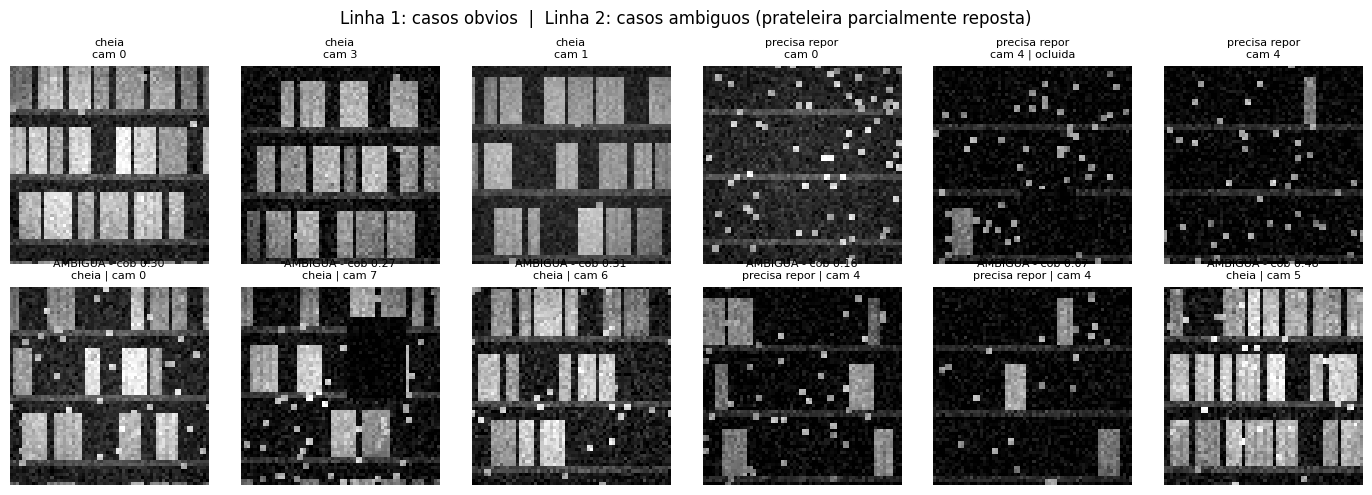

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
idx_cheia = np.where((y == 0) & ~eh_ambigua)[0][:3]
idx_vazia = np.where((y == 1) & ~eh_ambigua)[0][:3]
idx_amb   = np.where(eh_ambigua)[0][:6]

for ax, i in zip(axes[0], list(idx_cheia) + list(idx_vazia)):
    ax.imshow(X[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(('precisa repor' if y[i] else 'cheia') +
                 f'\ncam {camera[i]}' + (' | ocluida' if ocluido[i] else ''), fontsize=8)
    ax.axis('off')
for ax, i in zip(axes[1], idx_amb):
    ax.imshow(X[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'AMBIGUA - cob {cobertura[i]:.2f}\n' +
                 ('precisa repor' if y[i] else 'cheia') + f' | cam {camera[i]}', fontsize=8)
    ax.axis('off')

plt.suptitle('Linha 1: casos obvios  |  Linha 2: casos ambiguos (prateleira parcialmente reposta)')
plt.tight_layout()
plt.show()

Repare na segunda linha: são todas prateleiras parcialmente repostas, com cobertura próxima do limiar de 25%. Algumas estão de um lado da fronteira, outras do outro, e visualmente elas são muito parecidas. É esse subconjunto que separa um modelo útil de um modelo que só acerta o óbvio.

Repare também que a mesma categoria em câmeras diferentes produz imagens com brilho e enquadramento bem distintos — é exatamente por isso que o split precisa ser feito por câmera.

**4. Separação de dados: split por câmera**

Aqui está a diferença metodológica mais importante em relação à v1.

Um split aleatório colocaria imagens da **mesma câmera** no treino e no teste. O modelo aprenderia o fundo específico daquela gôndola, o brilho daquele corredor, o enquadramento daquela lente — e a acurácia de teste ficaria otimista. Quando o sistema chegasse a uma loja nova, o desempenho despencaria, e ninguém entenderia por quê.

Por isso separamos **por câmera**:

- **Treino:** câmeras 0 a 4
- **Validação:** câmera 5 — usada para *early stopping* e para calibrar o limiar de decisão
- **Teste:** câmeras 6 e 7 — **o modelo nunca as viu**

Isso simula a pergunta que o negócio realmente faz: *o modelo funciona em uma câmera que não estava no treino?*

In [7]:
CAMS_TREINO, CAMS_VAL, CAMS_TESTE = [0, 1, 2, 3, 4], [5], [6, 7]

m_tr = np.isin(camera, CAMS_TREINO)
m_va = np.isin(camera, CAMS_VAL)
m_te = np.isin(camera, CAMS_TESTE)

print(f'Treino:    {m_tr.sum():4d} imagens (cameras {CAMS_TREINO}) | precisa repor: {y[m_tr].mean():.1%}')
print(f'Validacao: {m_va.sum():4d} imagens (camera  {CAMS_VAL})    | precisa repor: {y[m_va].mean():.1%}')
print(f'Teste:     {m_te.sum():4d} imagens (cameras {CAMS_TESTE})  | precisa repor: {y[m_te].mean():.1%}')
print(f'\nCasos ambiguos no teste: {(m_te & eh_ambigua).sum()} de {m_te.sum()}')
print('Nenhuma camera aparece em dois conjuntos:',
      set(CAMS_TREINO).isdisjoint(CAMS_TESTE) and set(CAMS_VAL).isdisjoint(CAMS_TESTE))

Treino:     908 imagens (cameras [0, 1, 2, 3, 4]) | precisa repor: 48.9%
Validacao:  184 imagens (camera  [5])    | precisa repor: 52.7%
Teste:      348 imagens (cameras [6, 7])  | precisa repor: 52.0%

Casos ambiguos no teste: 131 de 348
Nenhuma camera aparece em dois conjuntos: True


**5. Degrau 1 — Baseline: limiar sobre a intensidade média**

A abordagem mais simples possível: calcular o brilho médio dos pixels e dizer que a seção precisa de reposição se esse valor ficar **abaixo** de um limiar.

O limiar é escolhido **no conjunto de treino** e aplicado sem alteração no teste. Escolher o limiar olhando o teste seria vazamento de dados clássico — e é um erro comum o suficiente para valer o destaque.

In [8]:
def brilho_medio(imgs):
    return imgs.reshape(len(imgs), -1).mean(axis=1)


brilho = brilho_medio(X)

candidatos = np.linspace(0.05, 0.60, 111)
melhor_limiar, melhor_acc = 0.0, 0.0
for t in candidatos:
    acc = accuracy_score(y[m_tr], (brilho[m_tr] < t).astype(int))
    if acc > melhor_acc:
        melhor_acc, melhor_limiar = acc, t

pred_base = (brilho[m_te] < melhor_limiar).astype(int)
prob_base = 1.0 - brilho[m_te]          # score continuo, para PR-AUC

print(f'Limiar escolhido no treino: {melhor_limiar:.3f} (acuracia de treino: {melhor_acc:.3f})')
print(f'Acuracia no teste: {accuracy_score(y[m_te], pred_base):.3f}')

Limiar escolhido no treino: 0.220 (acuracia de treino: 0.866)
Acuracia no teste: 0.894


**6. Degrau 2 — Features espaciais clássicas + Gradient Boosting**

Em vez de resumir a imagem a um único número (o brilho), descrevemos cada imagem com **nove medidas** escolhidas à mão — e deixamos um modelo de árvores combiná-las.

A hipótese por trás da escolha das features é que **massa conectada** importa: um bloco de produto é uma mancha clara *grande e contígua*, enquanto um reflexo de embalagem é um ponto claro *isolado*. Os dois somam brilho, mas só o primeiro tem estrutura. Por isso incluímos `maior_componente` (área do maior componente conexo claro), `n_componentes` e `area_media_componentes`, além de descritores de brilho e de bordas.

A célula seguinte mede, por permutação, quais dessas features o modelo de fato usa — e o resultado não é o que a hipótese previa.

In [9]:
NOMES_FEATURES = ['brilho_medio', 'desvio_padrao', 'frac_pixels_claros',
                  'maior_componente', 'n_componentes', 'area_media_componentes',
                  'cobertura_max_linha', 'cobertura_min_linha', 'densidade_bordas']


def extrair_features(imgs):
    """Nove descritores por imagem, com foco em estrutura espacial."""
    saida = []
    for im in imgs:
        binaria = im > 0.5
        rotulada, n = ndimage.label(binaria)
        if n > 0:
            areas = ndimage.sum(binaria, rotulada, range(1, n + 1))
            maior, media = areas.max() / binaria.size, areas.mean() / binaria.size
        else:
            maior = media = 0.0
        gy, gx = np.gradient(im)
        por_linha = binaria.mean(axis=1)
        saida.append([im.mean(), im.std(), binaria.mean(), maior, n / 100.0, media,
                      por_linha.max(), por_linha.min(), np.hypot(gx, gy).mean()])
    return np.array(saida)


F = extrair_features(X)
print('Matriz de features:', F.shape)

gb = HistGradientBoostingClassifier(max_iter=250, random_state=SEED)
gb.fit(F[m_tr], y[m_tr])

pred_gb = gb.predict(F[m_te])
prob_gb = gb.predict_proba(F[m_te])[:, 1]
print(f'Acuracia no teste: {accuracy_score(y[m_te], pred_gb):.3f}')

Matriz de features: (1440, 9)


Acuracia no teste: 0.922


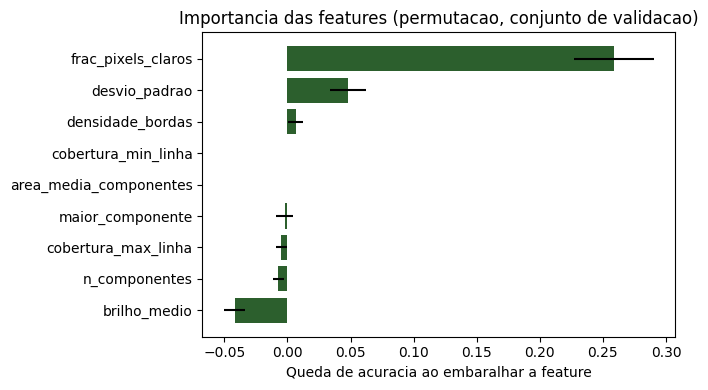

In [10]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(gb, F[m_va], y[m_va], n_repeats=10,
                             random_state=SEED, scoring='accuracy')
ordem = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(np.array(NOMES_FEATURES)[ordem], imp.importances_mean[ordem],
        xerr=imp.importances_std[ordem], color='#2C5F2D')
ax.set_xlabel('Queda de acuracia ao embaralhar a feature')
ax.set_title('Importancia das features (permutacao, conjunto de validacao)')
plt.tight_layout(); plt.show()

**Lendo o gráfico com honestidade**

A hipótese era que `maior_componente` seria a feature decisiva. O gráfico diz outra coisa: quem domina é **`frac_pixels_claros`** (a fração de pixels acima do limiar de brilho), com `desvio_padrao` em segundo lugar bem distante. `maior_componente` fica **próxima de zero**, e `brilho_medio` aparece com importância **negativa**.

Vale entender o que isso significa antes de concluir que a hipótese estava errada:

- **Importância por permutação subestima features correlacionadas.** `frac_pixels_claros`, `maior_componente` e `area_media_componentes` medem coisas parecidas. Ao embaralhar uma delas, o modelo recupera a informação pelas outras, e a queda de acurácia não aparece. Isso mede *o quanto aquela feature é insubstituível*, não *o quanto a informação dela importa*.
- **Importância negativa** indica que, no conjunto de validação (uma câmera que o modelo não treinou), embaralhar `brilho_medio` chegou a *melhorar* levemente a acurácia — sinal de que o modelo aprendeu a usar o brilho de um jeito que não transfere entre câmeras. É a mesma fragilidade que derruba o baseline, aparecendo aqui em escala menor.
- **`frac_pixels_claros` já é uma medida espacial**, ainda que grosseira: ela conta pixels acima de um limiar, o que é bem mais robusto a reflexo pontual do que a média global. Ou seja, a direção da hipótese se sustenta — o modelo prefere contagem de área clara a brilho médio — mas o refinamento por componentes conexos não trouxe ganho adicional detectável.

O exercício 3 propõe testar isso do jeito certo: **ablação**, retreinando o modelo sem cada feature, em vez de apenas embaralhá-la em um modelo já treinado.

**7. Degrau 3 — CNN com data augmentation**

Agora a rede convolucional. Três diferenças em relação à CNN da v1, todas endereçando a instabilidade diagnosticada lá:

- **Data augmentation** (espelhamento, translação, variação de brilho e contraste) — multiplica artificialmente a variedade do treino e força a rede a não decorar o enquadramento de uma câmera específica.
- **`GlobalAveragePooling` no lugar de `Flatten`** — reduz drasticamente o número de parâmetros densos e o risco de decorar posições absolutas.
- **`Dropout` + *early stopping*** sobre a perda de validação (a câmera 5, que a rede não treina) — em vez de um número fixo de épocas.

In [11]:
def construir_cnn(seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    aumento = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomBrightness(0.15, value_range=(0, 1)),
        layers.RandomContrast(0.15),
    ], name='augmentation')

    modelo = keras.Sequential([
        layers.Input(shape=(TAMANHO, TAMANHO, 1)),
        aumento,
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return modelo


cnn = construir_cnn()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                       restore_best_weights=True)

historico = cnn.fit(
    X[m_tr][..., None], y[m_tr],
    validation_data=(X[m_va][..., None], y[m_va]),
    epochs=40, batch_size=32, verbose=0, callbacks=[parada],
)

n_epocas = len(historico.history['loss'])
print(f'Treino encerrado na epoca {n_epocas} (early stopping).')
print(f"Acuracia final -- treino: {historico.history['accuracy'][-1]:.3f} | "
      f"validacao: {historico.history['val_accuracy'][-1]:.3f}")

prob_cnn = cnn.predict(X[m_te][..., None], verbose=0).ravel()
pred_cnn = (prob_cnn > 0.5).astype(int)
print(f'Acuracia no teste: {accuracy_score(y[m_te], pred_cnn):.3f}')

Treino encerrado na epoca 14 (early stopping).
Acuracia final -- treino: 0.950 | validacao: 0.897


Acuracia no teste: 0.957


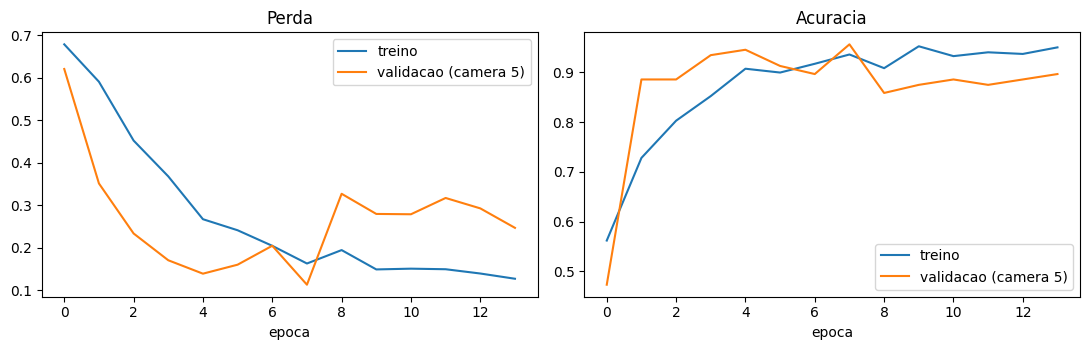

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(historico.history['loss'], label='treino')
axes[0].plot(historico.history['val_loss'], label='validacao (camera 5)')
axes[0].set_title('Perda'); axes[0].set_xlabel('epoca'); axes[0].legend()
axes[1].plot(historico.history['accuracy'], label='treino')
axes[1].plot(historico.history['val_accuracy'], label='validacao (camera 5)')
axes[1].set_title('Acuracia'); axes[1].set_xlabel('epoca'); axes[1].legend()
plt.tight_layout(); plt.show()

**8. Avaliação completa: além da acurácia**

Acurácia sozinha engana. Um modelo que responde sempre "cheia" acerta a maior parte do tempo em uma loja real (onde a prateleira quase sempre está abastecida) e é inútil.

As métricas que importam aqui, com **`y = 1` significando "precisa de reposição"**:

- **Recall** — das rupturas que realmente aconteceram, quantas o modelo detectou? É a métrica que traduz a dor de negócio: recall baixo = venda perdida.
- **Precisão** — dos alertas emitidos, quantos eram ruptura de verdade? Precisão baixa = repositor se deslocando à toa, e confiança na ferramenta se dissolvendo.
- **PR-AUC** — qualidade do ranqueamento em toda a faixa de limiares, independente do corte escolhido.
- **Acurácia nos casos ambíguos** — o recorte difícil, onde a decisão de negócio de fato se joga.

In [14]:
def avaliar(nome, y_true, y_pred, y_score, mascara_amb):
    return {
        'modelo': nome,
        'acuracia': accuracy_score(y_true, y_pred),
        'precisao': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_score),
        'acc_ambiguos': accuracy_score(y_true[mascara_amb], y_pred[mascara_amb]),
    }


amb_te = eh_ambigua[m_te]
resultados = pd.DataFrame([
    avaliar('Baseline (limiar)', y[m_te], pred_base, prob_base, amb_te),
    avaliar('Features + Boosting', y[m_te], pred_gb, prob_gb, amb_te),
    avaliar('CNN + augmentation', y[m_te], pred_cnn, prob_cnn, amb_te),
]).set_index('modelo').round(3)

display(resultados)

,acuracia,precisao,recall,f1,pr_auc,acc_ambiguos
modelo,,,,,,
Baseline (limiar),0.894,0.980,0.812,0.888,0.982,0.718
Features + Boosting,0.922,0.994,0.856,0.920,0.995,0.794
CNN + augmentation,0.957,0.977,0.939,0.958,0.996,0.885


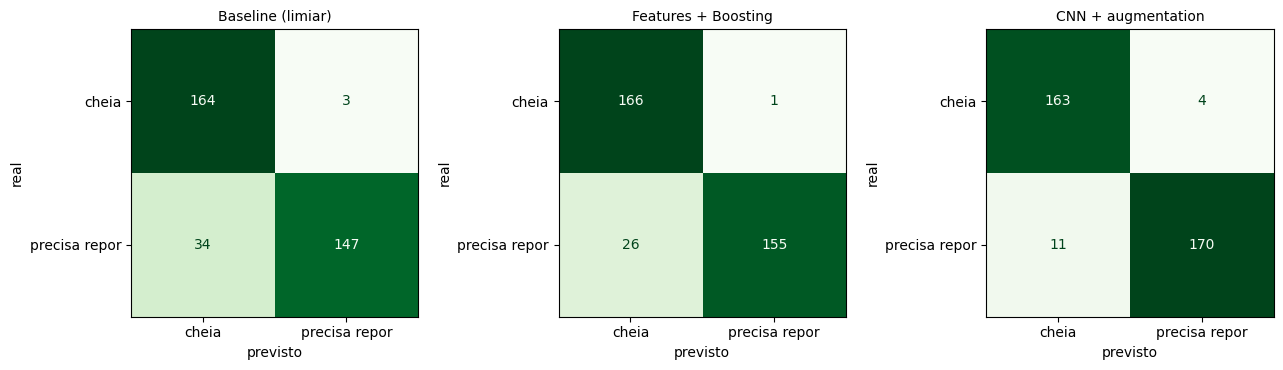

Canto inferior esquerdo = FALSO NEGATIVO: ruptura que passou despercebida (venda perdida).
Canto superior direito  = FALSO POSITIVO: repositor deslocado a toa (desgasta a confianca).


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (nome, pred) in zip(axes, [('Baseline (limiar)', pred_base),
                                   ('Features + Boosting', pred_gb),
                                   ('CNN + augmentation', pred_cnn)]):
    cm = confusion_matrix(y[m_te], pred)
    ConfusionMatrixDisplay(cm, display_labels=['cheia', 'precisa repor']).plot(
        ax=ax, cmap='Greens', colorbar=False, values_format='d')
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel('previsto'); ax.set_ylabel('real')
plt.tight_layout(); plt.show()

print('Canto inferior esquerdo = FALSO NEGATIVO: ruptura que passou despercebida (venda perdida).')
print('Canto superior direito  = FALSO POSITIVO: repositor deslocado a toa (desgasta a confianca).')

**9. Calibrando o limiar de decisão pelo custo de negócio**

O corte de 0,5 sobre a probabilidade é uma convenção de biblioteca, não uma decisão de negócio. Os dois erros não custam a mesma coisa:

- **Falso negativo** (ruptura não detectada): venda perdida, e possivelmente o cliente indo ao concorrente.
- **Falso positivo** (alerta em prateleira cheia): alguns minutos de deslocamento do repositor.

Adotamos como premissa **custo_FN = 5 × custo_FP** e varremos os limiares possíveis **no conjunto de validação** — nunca no de teste — escolhendo o que minimiza o custo esperado. Depois aplicamos esse limiar, sem alteração, no teste.

Trocar essa razão de custo é uma decisão de diretoria, não de cientista de dados: ela move o sistema ao longo do trade-off entre perder ruptura e incomodar a operação.

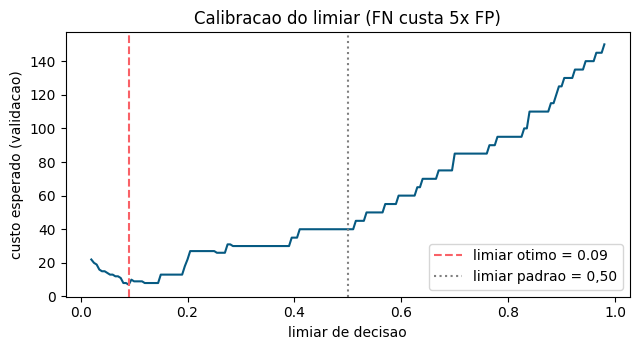

,acuracia,precisao,recall,f1,pr_auc,acc_ambiguos
modelo,,,,,,
"CNN @ 0,50 (padrao)",0.957,0.977,0.939,0.958,0.996,0.885
CNN @ 0.09 (por custo),0.865,0.794,1.000,0.885,0.996,0.672


Falsos negativos (rupturas perdidas): 11 -> 0
Falsos positivos (alertas a toa):     4 -> 47
Custo total no teste: 59 -> 47


In [16]:
CUSTO_FN, CUSTO_FP = 5.0, 1.0

prob_val_cnn = cnn.predict(X[m_va][..., None], verbose=0).ravel()


def limiar_por_custo(y_val, prob_val, custo_fn=CUSTO_FN, custo_fp=CUSTO_FP):
    grade = np.linspace(0.02, 0.98, 193)
    custos = []
    for t in grade:
        pred = (prob_val > t).astype(int)
        fn = int(((pred == 0) & (y_val == 1)).sum())
        fp = int(((pred == 1) & (y_val == 0)).sum())
        custos.append(custo_fn * fn + custo_fp * fp)
    custos = np.array(custos)
    return float(grade[custos.argmin()]), grade, custos


limiar_neg, grade, custos = limiar_por_custo(y[m_va], prob_val_cnn)
pred_cnn_cal = (prob_cnn > limiar_neg).astype(int)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(grade, custos, color='#065A82')
ax.axvline(limiar_neg, color='#F96167', ls='--',
           label=f'limiar otimo = {limiar_neg:.2f}')
ax.axvline(0.5, color='gray', ls=':', label='limiar padrao = 0,50')
ax.set_xlabel('limiar de decisao'); ax.set_ylabel('custo esperado (validacao)')
ax.set_title(f'Calibracao do limiar (FN custa {CUSTO_FN:.0f}x FP)')
ax.legend(); plt.tight_layout(); plt.show()

comparacao = pd.DataFrame([
    avaliar(f'CNN @ 0,50 (padrao)', y[m_te], pred_cnn, prob_cnn, amb_te),
    avaliar(f'CNN @ {limiar_neg:.2f} (por custo)', y[m_te], pred_cnn_cal, prob_cnn, amb_te),
]).set_index('modelo').round(3)
display(comparacao)

cm0 = confusion_matrix(y[m_te], pred_cnn); cm1 = confusion_matrix(y[m_te], pred_cnn_cal)
print(f'Falsos negativos (rupturas perdidas): {cm0[1, 0]} -> {cm1[1, 0]}')
print(f'Falsos positivos (alertas a toa):     {cm0[0, 1]} -> {cm1[0, 1]}')
print(f'Custo total no teste: {CUSTO_FN * cm0[1, 0] + CUSTO_FP * cm0[0, 1]:.0f} -> '
      f'{CUSTO_FN * cm1[1, 0] + CUSTO_FP * cm1[0, 1]:.0f}')

**10. Comparação lado a lado**

Duas visões: o desempenho no teste completo e no subconjunto ambíguo — que é onde a decisão de negócio realmente se joga, já que os casos óbvios praticamente qualquer abordagem acerta.

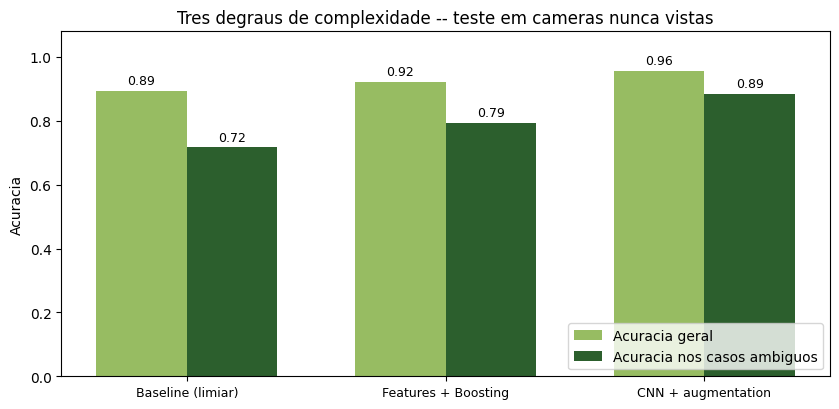

In [17]:
nomes = list(resultados.index)
x_pos = np.arange(len(nomes)); largura = 0.35
cores = ['#97BC62', '#2C5F2D']

fig, ax = plt.subplots(figsize=(8.5, 4.2))
b1 = ax.bar(x_pos - largura / 2, resultados['acuracia'], largura,
            label='Acuracia geral', color=cores[0])
b2 = ax.bar(x_pos + largura / 2, resultados['acc_ambiguos'], largura,
            label='Acuracia nos casos ambiguos', color=cores[1])
ax.set_xticks(x_pos); ax.set_xticklabels(nomes, fontsize=9)
ax.set_ylabel('Acuracia'); ax.set_ylim(0, 1.08)
ax.set_title('Tres degraus de complexidade -- teste em cameras nunca vistas')
ax.legend(loc='lower right')
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
                f'{b.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

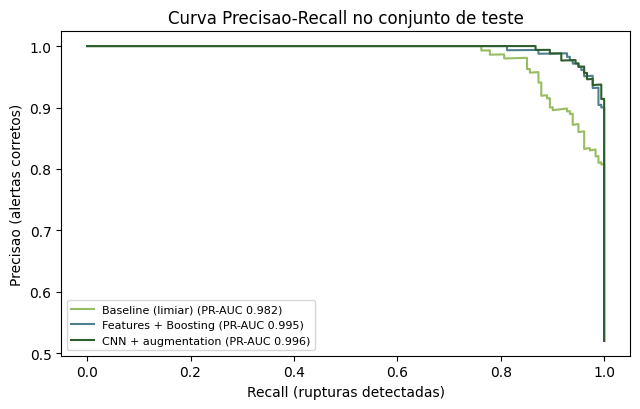

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for nome, score, cor in [('Baseline (limiar)', prob_base, '#97BC62'),
                         ('Features + Boosting', prob_gb, '#50808E'),
                         ('CNN + augmentation', prob_cnn, '#2C5F2D')]:
    p, r, _ = precision_recall_curve(y[m_te], score)
    ax.plot(r, p, label=f'{nome} (PR-AUC {average_precision_score(y[m_te], score):.3f})', color=cor)
ax.set_xlabel('Recall (rupturas detectadas)'); ax.set_ylabel('Precisao (alertas corretos)')
ax.set_title('Curva Precisao-Recall no conjunto de teste'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**11. Validação com múltiplas seeds**

Esta é a lição mais dura da v1: um resultado obtido com uma seed só pode ser acidente da amostra. Lá, a conclusão "o baseline vence" se invertia dependendo da seed, e a CNN oscilava de 40% a 83% nos casos ambíguos.

Aqui repetimos **todo o pipeline** — geração do dataset, escolha do limiar, extração de features, treino do boosting e treino da CNN do zero — para três seeds, **rodando também as câmeras de teste** (cada seed testa em um par diferente de câmeras). Reportamos média **e desvio-padrão**.

O desvio-padrão é o número que diz se dá para confiar na conclusão.

In [19]:
SEEDS = [42, 7, 123]
ROTACAO_CAMERAS = {42: ([0, 1, 2, 3, 4], [5], [6, 7]),
                   7:  ([2, 3, 4, 5, 6], [7], [0, 1]),
                   123: ([4, 5, 6, 7, 0], [1], [2, 3])}

linhas = []
for seed in SEEDS:
    print(f'--- seed {seed} ---')
    np.random.seed(seed); tf.keras.utils.set_random_seed(seed)
    rng_s = np.random.default_rng(seed)

    Xs, ys, cams, ambs, cobs, ocs = gerar_dataset(rng_s)
    c_tr, c_va, c_te = ROTACAO_CAMERAS[seed]
    tr, va, te = np.isin(cams, c_tr), np.isin(cams, c_va), np.isin(cams, c_te)
    amb_t = ambs[te]

    # degrau 1
    br = brilho_medio(Xs)
    lim, best = 0.0, 0.0
    for t in candidatos:
        a = accuracy_score(ys[tr], (br[tr] < t).astype(int))
        if a > best:
            best, lim = a, t
    p_base, s_base = (br[te] < lim).astype(int), 1.0 - br[te]

    # degrau 2
    Fs = extrair_features(Xs)
    gb_s = HistGradientBoostingClassifier(max_iter=250, random_state=seed).fit(Fs[tr], ys[tr])
    p_gb, s_gb = gb_s.predict(Fs[te]), gb_s.predict_proba(Fs[te])[:, 1]

    # degrau 3
    cnn_s = construir_cnn(seed)
    cnn_s.fit(Xs[tr][..., None], ys[tr], validation_data=(Xs[va][..., None], ys[va]),
              epochs=40, batch_size=32, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                                       restore_best_weights=True)])
    s_cnn = cnn_s.predict(Xs[te][..., None], verbose=0).ravel()
    p_cnn = (s_cnn > 0.5).astype(int)

    for nome, p, s in [('Baseline (limiar)', p_base, s_base),
                       ('Features + Boosting', p_gb, s_gb),
                       ('CNN + augmentation', p_cnn, s_cnn)]:
        r = avaliar(nome, ys[te], p, s, amb_t)
        r['seed'] = seed
        linhas.append(r)
        print(f"  {nome:22s} acc {r['acuracia']:.3f} | recall {r['recall']:.3f} | ambiguos {r['acc_ambiguos']:.3f}")

df_seeds = pd.DataFrame(linhas)

--- seed 42 ---


  Baseline (limiar)      acc 0.894 | recall 0.812 | ambiguos 0.718
  Features + Boosting    acc 0.922 | recall 0.856 | ambiguos 0.794
  CNN + augmentation     acc 0.957 | recall 0.939 | ambiguos 0.885
--- seed 7 ---


  Baseline (limiar)      acc 0.813 | recall 0.613 | ambiguos 0.593
  Features + Boosting    acc 0.930 | recall 0.856 | ambiguos 0.807
  CNN + augmentation     acc 0.965 | recall 0.983 | ambiguos 0.904
--- seed 123 ---


  Baseline (limiar)      acc 0.924 | recall 0.971 | ambiguos 0.822
  Features + Boosting    acc 0.905 | recall 0.914 | ambiguos 0.752
  CNN + augmentation     acc 0.964 | recall 0.983 | ambiguos 0.871


In [20]:
print('Resultado por seed (acuracia geral / acuracia nos ambiguos):')
display(df_seeds.pivot_table(index='seed', columns='modelo',
                             values=['acuracia', 'acc_ambiguos']).round(3))

print('\nMedia e desvio-padrao entre as 3 seeds:')
resumo_seeds = (df_seeds.groupby('modelo')[['acuracia', 'recall', 'precisao', 'acc_ambiguos']]
                .agg(['mean', 'std']).round(3))
display(resumo_seeds)

Resultado por seed (acuracia geral / acuracia nos ambiguos):


acc_ambiguos                                         \
modelo Baseline (limiar) CNN + augmentation Features + Boosting   
seed                                                              
7                  0.593              0.904               0.807   
42                 0.718              0.885               0.794   
123                0.822              0.871               0.752   

                acuracia                                         
modelo Baseline (limiar) CNN + augmentation Features + Boosting  
seed                                                             
7                  0.813              0.965               0.930  
42                 0.894              0.957               0.922  
123                0.924              0.964               0.905


Media e desvio-padrao entre as 3 seeds:


acuracia        recall        precisao         \
                        mean    std   mean    std     mean    std   
modelo                                                              
Baseline (limiar)      0.877  0.058  0.799  0.179    0.955  0.061   
CNN + augmentation     0.962  0.004  0.969  0.025    0.956  0.018   
Features + Boosting    0.919  0.013  0.876  0.033    0.962  0.060   

                    acc_ambiguos         
                            mean    std  
modelo                                   
Baseline (limiar)          0.711  0.115  
CNN + augmentation         0.887  0.016  
Features + Boosting        0.785  0.029

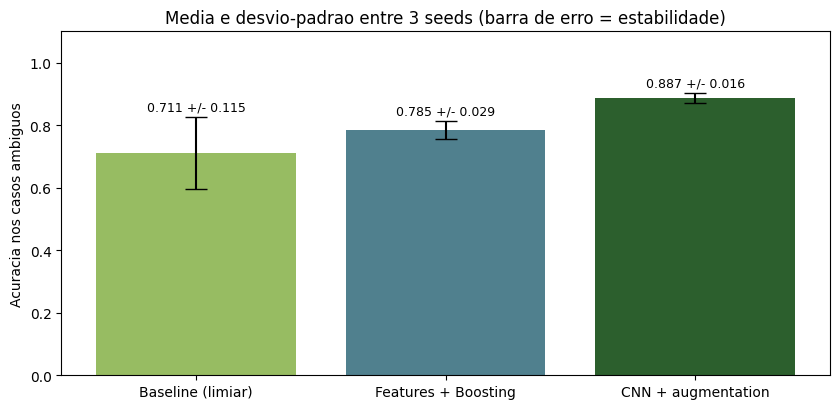

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ordem_m = ['Baseline (limiar)', 'Features + Boosting', 'CNN + augmentation']
med = df_seeds.groupby('modelo')['acc_ambiguos'].mean().reindex(ordem_m)
dp = df_seeds.groupby('modelo')['acc_ambiguos'].std().reindex(ordem_m)
ax.bar(ordem_m, med, yerr=dp, capsize=8, color=['#97BC62', '#50808E', '#2C5F2D'])
for i, (m, d) in enumerate(zip(med, dp)):
    ax.text(i, m + d + 0.02, f'{m:.3f} +/- {d:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Acuracia nos casos ambiguos'); ax.set_ylim(0, 1.1)
ax.set_title('Media e desvio-padrao entre 3 seeds (barra de erro = estabilidade)')
plt.tight_layout(); plt.show()

**12. Veredito honesto**

Os números abaixo foram gerados por esta própria execução, testando sempre em câmeras que os modelos nunca viram.

**Média e desvio-padrão entre as 3 seeds:**

| Modelo | Acurácia geral | Recall | Acurácia nos ambíguos |
|---|---|---|---|
| Baseline (limiar) | 0,877 ± 0,058 | 0,799 ± 0,179 | 0,711 ± 0,115 |
| Features + Boosting | 0,919 ± 0,013 | 0,876 ± 0,033 | 0,785 ± 0,029 |
| **CNN + augmentation** | **0,962 ± 0,004** | **0,969 ± 0,025** | **0,887 ± 0,016** |

**A conclusão da v1 se inverteu — e o motivo importa mais que o resultado.**

Na v1, o baseline de brilho médio venceu a CNN e a rede foi o modelo instável. Aqui acontece o oposto, nos dois eixos:

1. **A escada de complexidade se paga, degrau por degrau.** Nos casos ambíguos — o recorte que decide o negócio — o desempenho sobe de 0,711 (limiar) para 0,785 (features espaciais) e para 0,887 (CNN). Cada degrau adiciona algo real: o segundo enxerga estrutura espacial que o brilho médio ignora, e o terceiro descobre padrões que ninguém precisou especificar à mão.

2. **A estabilidade trocou de lado.** Este é o achado mais interessante. Nos casos ambíguos, o desvio-padrão do baseline entre seeds é **0,115** e o da CNN é **0,016** — sete vezes menor. O baseline agora é o modelo frágil, e o motivo é direto: seu único parâmetro é um limiar de brilho global, e cada câmera tem seu próprio ganho, offset e vinheta. Um limiar calibrado nas câmeras 0-4 simplesmente não transfere para as câmeras 6-7. Na seed 7 isso fica cru: o recall do baseline cai para 0,613, ou seja, **quase 40% das rupturas passam despercebidas**.

**Por que a v1 chegou ao contrário?** Não porque CNNs sejam ruins ou boas por natureza, mas porque lá **não havia estrutura visual a explorar**: imagens de 16×16, uma única condição de captura, rótulo derivado de blocos que empurravam diretamente o brilho médio. Sem variação de câmera nem oclusão, o brilho médio era quase um resumo suficiente do rótulo, e a rede tinha poucos exemplos para aprender algo melhor. Ao introduzir aquilo que existe em fotos reais — múltiplas câmeras, iluminação variável, oclusão, reflexo — o problema passou a ter a estrutura que justifica a rede, e a diferença apareceu.

**A lição para o negócio não mudou; ela apenas ficou completa:** o ganho de uma rede neural não é automático, mas também não é ilusório. Ele depende de o problema ter complexidade visual real e de a validação ser honesta o bastante para revelá-la. Um teste com split aleatório teria inflado os três modelos e escondido justamente a fragilidade do baseline entre câmeras — que é o modo de falha que apareceria na prática, quando o sistema chegasse a uma loja nova.

---

**Sobre a calibração por custo (seção 9), uma ressalva importante**

Com a razão custo_FN = 5 × custo_FP, o limiar ótimo na validação caiu de 0,50 para **0,09**, e o efeito no teste foi drástico: os falsos negativos foram de **11 para 0** (nenhuma ruptura perdida) e os falsos positivos de **4 para 47**. O custo total caiu de 59 para 47 — a calibração fez o que prometeu.

Mas olhe a precisão: **0,977 para 0,794**. Isso significa que **1 em cada 5 alertas passa a ser falso**. Se o projeto adotou um teto de 15% de alarme falso como condição de adoção — e há boa razão para isso, porque um repositor que não confia no alerta para de atendê-lo —, então **esta calibração viola o teto**, mesmo sendo ótima pela função de custo. 

A lição é que a razão de custo escolhida no papel precisa ser confrontada com a restrição operacional real. Ou se aceita perder algumas rupturas, ou se aumenta a capacidade da equipe, ou se melhora o modelo até que ele consiga recall alto *sem* pagar em precisão. O exercício 2 explora exatamente esse trade-off.

**13. Do notebook para o projeto**

O que este notebook cobre e o que fica de fora, mapeado no plano de projeto de IA:

| Etapa do plano | Aqui | Em produção |
|---|---|---|
| Coleta de dados | Simulação com 8 perfis de câmera | Câmeras reais + planograma + ERP + PDV |
| Rotulagem | Regra determinística sobre a cobertura | Rotulagem humana, com dupla checagem na faixa ambígua |
| Split | Por câmera | Por câmera **e** por loja **e** corte temporal |
| Modelos | Limiar, features+boosting, CNN | Acrescentar *transfer learning* (MobileNet/EfficientNet) |
| Validação | 3 seeds, rotação de câmeras | *Cross-validation* por loja + avaliação por segmento (refrigerado/seco, faixa horária) |
| Limiar de decisão | Calibrado por custo na validação | Recalibrado periodicamente, com a razão de custo definida pelo negócio |
| Deploy | — | Inferência na borda, alerta no app do repositor |
| Monitoramento | — | *Data drift* (brilho, contraste por câmera), *concept drift* (mudança de planograma), taxa de alertas confirmados |

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui — classificar imagens automaticamente com visão computacional, comparando níveis de complexidade antes de escolher — se aplica a diversos outros problemas:

### 1. Manufatura
- **Controle de qualidade automático:** detectar defeitos milimétricos em produtos na linha de montagem, invisíveis a olho nu. O mesmo cuidado vale: comece por uma regra de limiar sobre a área do defeito antes de partir para a rede.

### 2. Agronegócio
- **Monitoramento de safras via satélite ou drone:** identificar áreas com problema de plantio, praga ou necessidade de irrigação. O split por talhão é o análogo direto do split por câmera usado aqui.

### 3. Segurança
- **Monitoramento de câmeras:** contar pessoas ou veículos e detectar comportamentos atípicos. A calibração de limiar por custo é essencial — o custo de um alarme falso às 3h da manhã não é o mesmo de uma intrusão não detectada.

### 4. Gestão de Documentos
- **Leitura e classificação automática de documentos (OCR + classificação):** digitalizar e rotear documentos em escala. O equivalente ao "perfil de câmera" aqui é o scanner/celular que digitalizou — e ele precisa entrar no split.

**Exercícios**

Escolha um dos exercícios abaixo e resolva reaproveitando as funções deste notebook (`gerar_imagem_gondola`, `gerar_dataset`, `extrair_features`, `construir_cnn`, `avaliar`).

1. **Quanto o split por câmera está custando?** Refaça a avaliação dos três modelos usando um split **aleatório** (`train_test_split` com `stratify=y`) em vez do split por câmera, mantendo as mesmas proporções. Quanto a acurácia de cada modelo sobe? Qual dos três mais se beneficia do vazamento? Por que a CNN tende a ser a mais afetada — o que exatamente ela consegue decorar quando a mesma câmera aparece nos dois conjuntos?

2. **A razão de custo muda o sistema.** A seção 9 assume que um falso negativo custa 5× um falso positivo. Varra essa razão de 1 a 20, e para cada valor recalibre o limiar na validação e registre recall, precisão e número de alertas emitidos por dia no teste. Monte o gráfico dessa curva. A partir de que razão o sistema passa a emitir mais alertas do que a equipe consegue atender — e como você apresentaria esse trade-off à diretoria?

3. **Ablação das features espaciais.** Retreine o modelo do degrau 2 removendo uma feature por vez e meça a queda de desempenho. A hipótese central do notebook é que `maior_componente` é a feature que separa produto de reflexo: ela se confirma? Em seguida, treine um boosting **apenas** com `brilho_medio` — ele empata com o baseline de limiar, como se espera?

4. **Quanto de oclusão o sistema aguenta?** Aumente a probabilidade de oclusão em `gerar_imagem_gondola` de 20% para 40% e 60%, refazendo a comparação dos três modelos em cada nível. Qual abordagem se degrada mais rápido? Isso é consistente com a ideia de que a CNN, por aprender padrões espaciais locais, deveria resistir melhor a uma região da imagem ser apagada?